# 02. PID ↔ 元数据 Join 完整性检查

> 对应 `analysis_plan.md` §2.2。**依赖 §2.1 已产出的 `_cache.pkl`**（如果没跑请先跑 `01_sid_distribution.ipynb`）。

## 目的

SID / Caption / Tag 三张表通过 `(domain, pid)` 复合主键关联。本 notebook 回答：

1. **覆盖率矩阵**：每个 domain 有多少 pid 同时具备 SID / Caption / Tag？孤儿 pid 有多少？
2. **Caption 类型判别**：caption 是**自然语言描述**（`describe`）还是**字符串化的 tag list**（`taglist`）？各 domain 各占多少？
3. **孤儿 pid 清单**：把没 caption / 没 tag 的 pid 单独导出，供后续 SFT 样本构造脚本 filter。

## 三张表规模（确认）

| 表 | files | rows | size |
|---|---|---|---|
| Pid2Sid | 198 | 35.9M | 0.52 GB |
| Pid2Caption | 136 | 21.1M | 6.06 GB |
| Pid2Tag | 31 | 5.4M | 0.06 GB |

→ 单靠 pid 数量就知道：**一定有大量 pid 无 tag，也有相当比例 pid 无 caption**。这里我们要精确算出每个 domain 的覆盖情况。

## 输入 / 输出

**输入**：
- `dataset_rec_all/data/OneReason_Pid2Sid/*.parquet`
- `dataset_rec_all/data/OneReason_Pid2Caption/*.parquet`
- `dataset_rec_all/data/OneReason_Pid2Tag/*.parquet`

**输出**（`analysis/outputs/join/`）：
- `coverage_matrix.csv` —— 每 domain × {has_sid, has_caption, has_tag} 覆盖率
- `venn_{domain}.png` —— 每 domain 的三集合韦恩图
- `caption_type_stats.csv` —— caption 是 describe / taglist / short-noise 的分布
- `orphan_pids_no_caption_{domain}.parquet` —— 有 SID 但无 caption 的 pid
- `orphan_pids_no_sid_caption.parquet` —— 有 caption 但无 SID 的 pid（异常）
- `_pid_sets_cache.pkl` —— 每 domain 的 pid 集合（供后续 notebook 复用）

In [1]:
# ============ 配置 & imports ============
import os
import pickle
import time
import re
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ---- 路径 ----
PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
DATA_DIR     = PROJECT_ROOT / 'dataset_rec_all' / 'data'
PID2SID_DIR  = DATA_DIR / 'OneReason_Pid2Sid'
PID2CAP_DIR  = DATA_DIR / 'OneReason_Pid2Caption'
PID2TAG_DIR  = DATA_DIR / 'OneReason_Pid2Tag'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'join'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PID_SETS_CACHE = OUT_DIR / '_pid_sets_cache.pkl'
CAP_STAT_CACHE = OUT_DIR / '_caption_type_cache.pkl'

# ---- 参数 ----
SAMPLE_FRAC = 1.0    # 试跑改 0.02
USE_CACHE   = True   # 有缓存就直接读
CAP_SAMPLE_FRAC = 0.02  # caption 类型判别只需抽样即可（6GB 全量太贵）

print('Pid2Sid dir     :', PID2SID_DIR)
print('Pid2Caption dir :', PID2CAP_DIR)
print('Pid2Tag dir     :', PID2TAG_DIR)
print('Output dir      :', OUT_DIR)

Pid2Sid dir     : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Sid
Pid2Caption dir : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Caption
Pid2Tag dir     : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Tag
Output dir      : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join


## 步骤 1：收集三张表在每个 domain 下的 pid 集合

只读 `pid` + `domain` 两列，把每 domain 的 pid 存成 numpy int64 数组。

> 内存估算：3591 万 pid × 8B = **约 285 MB**（一次装下没问题），Caption 2106 万 × 8B = 168 MB。用 python `set` 反而慢又费内存 → 用 numpy 数组 + `np.isin` / `np.setdiff1d` 做集合运算。

In [2]:
def collect_pids_by_domain(directory: Path, sample_frac: float = 1.0):
    """扫描 parquet 目录，返回 {domain: np.ndarray[int64] of pids}"""
    parts_per_domain = defaultdict(list)  # domain -> list of np.ndarray
    files = sorted(directory.glob('part-*.parquet'))
    t0 = time.time()
    for i, fp in enumerate(files):
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=['pid', 'domain'])
            df = tbl.to_pandas()
            if sample_frac < 1.0:
                df = df.sample(frac=sample_frac, random_state=2026)
            for domain, sub in df.groupby('domain', sort=False):
                parts_per_domain[domain].append(sub['pid'].to_numpy(dtype=np.int64))
        if (i + 1) % 30 == 0 or i == len(files) - 1:
            print(f'  {directory.name}: {i+1}/{len(files)}  elapsed {time.time()-t0:.1f}s')
    result = {d: np.concatenate(a) if a else np.array([], dtype=np.int64) for d, a in parts_per_domain.items()}
    print(f'[OK] {directory.name} done in {time.time()-t0:.1f}s')
    return result


if USE_CACHE and PID_SETS_CACHE.exists():
    print(f'[cache] loading {PID_SETS_CACHE} ...')
    with open(PID_SETS_CACHE, 'rb') as f:
        sid_pids, cap_pids, tag_pids = pickle.load(f)
    print('[cache] loaded.')
else:
    print('=== scanning Pid2Sid ===')
    sid_pids = collect_pids_by_domain(PID2SID_DIR, SAMPLE_FRAC)
    print('=== scanning Pid2Caption ===')
    cap_pids = collect_pids_by_domain(PID2CAP_DIR, SAMPLE_FRAC)
    print('=== scanning Pid2Tag ===')
    tag_pids = collect_pids_by_domain(PID2TAG_DIR, SAMPLE_FRAC)
    with open(PID_SETS_CACHE, 'wb') as f:
        pickle.dump((sid_pids, cap_pids, tag_pids), f)
    print(f'[cache] saved to {PID_SETS_CACHE}')

print('\n=== domain 分布（原始 pid 行数，可能含重复） ===')
def _report(name, mp):
    print(f'{name}:')
    for d in sorted(mp):
        arr = mp[d]
        uniq = np.unique(arr).size
        print(f'  {d:<12s} rows={arr.size:>10,}  unique_pids={uniq:>10,}  dup_rate={(1-uniq/max(1,arr.size))*100:.2f}%')
_report('Pid2Sid    ', sid_pids)
_report('Pid2Caption', cap_pids)
_report('Pid2Tag    ', tag_pids)

[cache] loading /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/_pid_sets_cache.pkl ...
[cache] loaded.

=== domain 分布（原始 pid 行数，可能含重复） ===
Pid2Sid    :
  goods        rows=16,087,726  unique_pids=16,087,726  dup_rate=0.00%
  live         rows=   107,289  unique_pids=   107,289  dup_rate=0.00%
  video/ad     rows= 2,056,889  unique_pids= 2,056,889  dup_rate=0.00%
  video/video  rows=17,662,191  unique_pids=17,662,191  dup_rate=0.00%
Pid2Caption:
  goods        rows= 9,769,747  unique_pids= 9,769,747  dup_rate=0.00%
  live         rows=   106,953  unique_pids=   106,953  dup_rate=0.00%
  video/ad     rows= 1,423,643  unique_pids= 1,423,643  dup_rate=0.00%
  video/video  rows= 9,760,984  unique_pids= 9,760,984  dup_rate=0.00%
Pid2Tag    :
  live         rows=    60,231  unique_pids=    60,231  dup_rate=0.00%
  video/ad     rows=   742,085  unique_pids=   742,085  dup_rate=0.00%
  video/video  rows= 4,614,963  unique_pids= 4,614,963  dup_rate=0.00%


## 步骤 2：覆盖率矩阵

对每个 domain，计算：
- `|SID|`, `|Caption|`, `|Tag|`（unique pid 数）
- `|SID ∩ Caption|`, `|SID ∩ Tag|`, `|SID ∩ Caption ∩ Tag|`
- `has_sid_no_caption`（有 SID 但无 caption，**这些 pid 没法做懂物料任务**）
- `has_caption_no_sid`（有 caption 但无 SID，**异常状况**）

In [3]:
def to_uniq_set(arr):
    """np.array -> np.array of unique sorted ids (kept as np, memory friendlier than python set for large N)."""
    return np.unique(arr) if arr.size else np.array([], dtype=np.int64)

def size_of_intersect(a, b):
    return int(np.intersect1d(a, b, assume_unique=True).size)

all_domains = sorted(set(list(sid_pids.keys()) + list(cap_pids.keys()) + list(tag_pids.keys())))
print('all domains:', all_domains)

sid_u = {d: to_uniq_set(sid_pids.get(d, np.array([], dtype=np.int64))) for d in all_domains}
cap_u = {d: to_uniq_set(cap_pids.get(d, np.array([], dtype=np.int64))) for d in all_domains}
tag_u = {d: to_uniq_set(tag_pids.get(d, np.array([], dtype=np.int64))) for d in all_domains}

cov_rows = []
for d in all_domains:
    S, C, T = sid_u[d], cap_u[d], tag_u[d]
    SC = np.intersect1d(S, C, assume_unique=True)
    ST = np.intersect1d(S, T, assume_unique=True)
    SCT = np.intersect1d(SC, T, assume_unique=True)
    row = {
        'domain': d,
        '|SID|':      S.size,
        '|Caption|':  C.size,
        '|Tag|':      T.size,
        '|S∩C|':      SC.size,
        '|S∩T|':      ST.size,
        '|S∩C∩T|':    SCT.size,
        'caption_cov_of_sid_%': round(SC.size / max(1, S.size) * 100, 2),
        'tag_cov_of_sid_%':     round(ST.size / max(1, S.size) * 100, 2),
        'sid_no_caption':       int(S.size - SC.size),
        'sid_no_tag':           int(S.size - ST.size),
        'caption_no_sid':       int(C.size - SC.size),
        'tag_no_sid':           int(T.size - ST.size),
    }
    cov_rows.append(row)

cov_df = pd.DataFrame(cov_rows)
cov_df.to_csv(OUT_DIR / 'coverage_matrix.csv', index=False)
print('saved:', OUT_DIR / 'coverage_matrix.csv')
cov_df

all domains: ['goods', 'live', 'video/ad', 'video/video']
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/coverage_matrix.csv


,domain,|SID|,|Caption|,|Tag|,|S∩C|,|S∩T|,|S∩C∩T|,caption_cov_of_sid_%,tag_cov_of_sid_%,sid_no_caption,sid_no_tag,caption_no_sid,tag_no_sid
0,goods,16087726,9769747,0,9769747,0,0,60.73,0.00,6317979,16087726,0,0
1,live,107289,106953,60231,106953,60231,60135,99.69,56.14,336,47058,0,0
2,video/ad,2056889,1423643,742085,1423643,742085,519085,69.21,36.08,633246,1314804,0,0
3,video/video,17662191,9760984,4614963,9760984,4614963,3240877,55.26,26.13,7901207,13047228,0,0


## 步骤 3：每 domain 的三集合 Venn 图

> 使用 `matplotlib_venn`；如果没安装，回退到简单柱状图。

[warn] matplotlib_venn 未安装, 降级为条形图。可执行  pip install matplotlib-venn


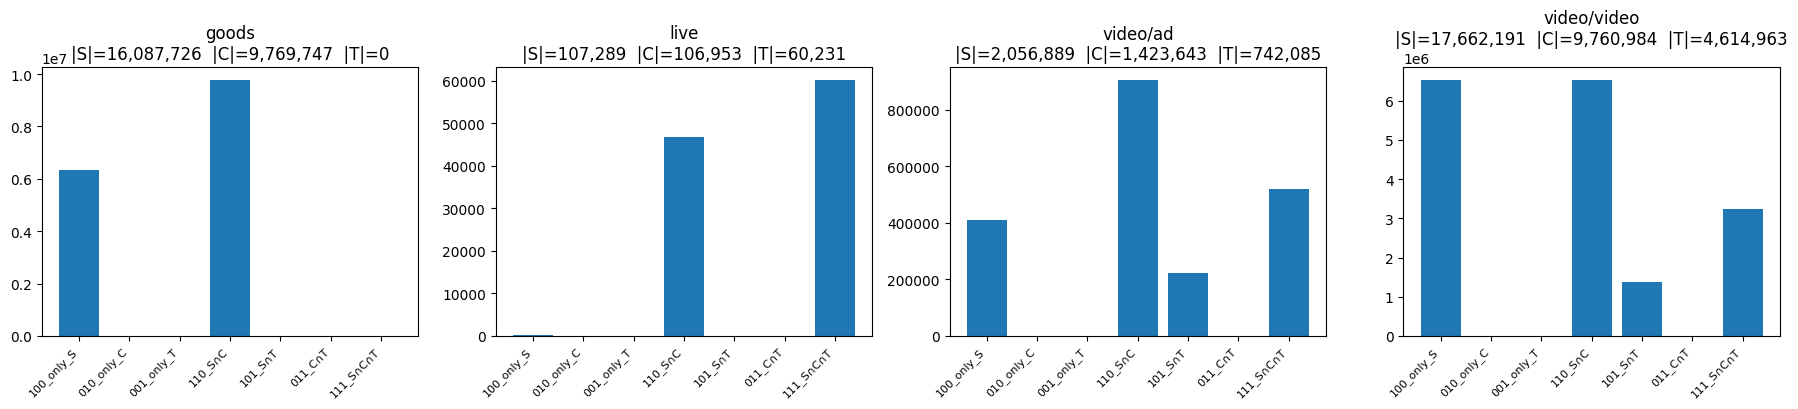

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/venn_regions.csv


,domain,100_only_S,010_only_C,001_only_T,110_S∩C,101_S∩T,011_C∩T,111_S∩C∩T
0,goods,6317979,0,0,9769747,0,0,0
1,live,240,0,0,46818,96,0,60135
2,video/ad,410246,0,0,904558,223000,0,519085
3,video/video,6527121,0,0,6520107,1374086,0,3240877


In [4]:
try:
    from matplotlib_venn import venn3
    HAS_VENN = True
except ImportError:
    HAS_VENN = False
    print('[warn] matplotlib_venn 未安装, 降级为条形图。可执行  pip install matplotlib-venn')


def _venn_regions(S, C, T):
    """返回 (100, 010, 001, 110, 101, 011, 111) 七元组对应的 pid 数量。"""
    SC  = np.intersect1d(S, C, assume_unique=True)
    ST  = np.intersect1d(S, T, assume_unique=True)
    CT  = np.intersect1d(C, T, assume_unique=True)
    SCT = np.intersect1d(SC, T, assume_unique=True)
    only_S  = S.size - SC.size - ST.size + SCT.size
    only_C  = C.size - SC.size - CT.size + SCT.size
    only_T  = T.size - ST.size - CT.size + SCT.size
    SC_only = SC.size - SCT.size
    ST_only = ST.size - SCT.size
    CT_only = CT.size - SCT.size
    return {
        '100_only_S':   only_S,
        '010_only_C':   only_C,
        '001_only_T':   only_T,
        '110_S∩C':      SC_only,
        '101_S∩T':      ST_only,
        '011_C∩T':      CT_only,
        '111_S∩C∩T':    int(SCT.size),
    }

region_rows = []
n = len(all_domains)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2), squeeze=False)
for i, d in enumerate(all_domains):
    S, C, T = sid_u[d], cap_u[d], tag_u[d]
    regions = _venn_regions(S, C, T)
    region_rows.append({'domain': d, **regions})
    ax = axes[0][i]
    if HAS_VENN and (S.size + C.size + T.size) > 0:
        subsets = (regions['100_only_S'], regions['010_only_C'], regions['110_S∩C'],
                   regions['001_only_T'], regions['101_S∩T'], regions['011_C∩T'],
                   regions['111_S∩C∩T'])
        venn3(subsets=subsets, set_labels=('SID', 'Caption', 'Tag'), ax=ax)
    else:
        ax.bar(range(len(regions)), list(regions.values()))
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(list(regions.keys()), rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{d}\n|S|={S.size:,}  |C|={C.size:,}  |T|={T.size:,}')

plt.tight_layout()
plt.savefig(OUT_DIR / 'venn_all_domains.png', dpi=110)
plt.show()

region_df = pd.DataFrame(region_rows)
region_df.to_csv(OUT_DIR / 'venn_regions.csv', index=False)
print('saved:', OUT_DIR / 'venn_regions.csv')
region_df

## 步骤 4：导出孤儿 pid 清单

两类关键孤儿：
1. `has_sid_no_caption`：**懂物料任务不能用它们**（因为没有描述文本），后面 SFT 样本构造时要 filter 掉。
2. `has_caption_no_sid`：异常情况 —— 有描述却没 SID，无法生成对齐的三段 token。也要 filter。

第 3 类 `has_sid_no_tag`：不影响物料任务（tag 只是辅助），但影响兴趣演化任务（主题匹配需要 tag）。所以也导出。

In [5]:
def _write_orphans(name, records):
    if not records:
        print(f'  {name}: (empty, nothing to write)')
        return
    df = pd.DataFrame(records)
    out = OUT_DIR / f'{name}.parquet'
    df.to_parquet(out, index=False)
    print(f'  {name}: rows={len(df):,}  ->  {out.name}')


for d in all_domains:
    S, C, T = sid_u[d], cap_u[d], tag_u[d]
    # (1) sid but no caption
    diff_S_C = np.setdiff1d(S, C, assume_unique=True)
    _write_orphans(
        f'orphan_sid_no_caption_{d.replace("/", "_")}',
        [{'pid': int(p), 'domain': d} for p in diff_S_C],
    )
    # (2) caption but no sid
    diff_C_S = np.setdiff1d(C, S, assume_unique=True)
    _write_orphans(
        f'orphan_caption_no_sid_{d.replace("/", "_")}',
        [{'pid': int(p), 'domain': d} for p in diff_C_S],
    )
    # (3) sid but no tag
    diff_S_T = np.setdiff1d(S, T, assume_unique=True)
    _write_orphans(
        f'orphan_sid_no_tag_{d.replace("/", "_")}',
        [{'pid': int(p), 'domain': d} for p in diff_S_T],
    )

print('\n[done] orphan lists exported to', OUT_DIR)

  orphan_sid_no_caption_goods: rows=6,317,979  ->  orphan_sid_no_caption_goods.parquet
  orphan_caption_no_sid_goods: (empty, nothing to write)
  orphan_sid_no_tag_goods: rows=16,087,726  ->  orphan_sid_no_tag_goods.parquet
  orphan_sid_no_caption_live: rows=336  ->  orphan_sid_no_caption_live.parquet
  orphan_caption_no_sid_live: (empty, nothing to write)
  orphan_sid_no_tag_live: rows=47,058  ->  orphan_sid_no_tag_live.parquet
  orphan_sid_no_caption_video_ad: rows=633,246  ->  orphan_sid_no_caption_video_ad.parquet
  orphan_caption_no_sid_video_ad: (empty, nothing to write)
  orphan_sid_no_tag_video_ad: rows=1,314,804  ->  orphan_sid_no_tag_video_ad.parquet
  orphan_sid_no_caption_video_video: rows=7,901,207  ->  orphan_sid_no_caption_video_video.parquet
  orphan_caption_no_sid_video_video: (empty, nothing to write)
  orphan_sid_no_tag_video_video: rows=13,047,228  ->  orphan_sid_no_tag_video_video.parquet

[done] orphan lists exported to /Users/cjs/Desktop/MY/explore_llm_rec/analys

## 步骤 5：Caption 类型判别（describe / taglist / short-noise）

从 §0 抽样看到，Caption 有两种明显不同的形态：

1. `describe`：一段自然语言描述，例如
   > 该视频主要面向美食爱好者，记录了一位女性在家制作并享用美食的过程 ...
2. `taglist`：字符串化的 tag list（可 `ast.literal_eval` 解析），例如
   > `['粉嫩双马尾游戏角色', '和平精英技术流', '不露脸直播', ...]`

**判别规则**：
- 首字符 `[` + 末字符 `]` + 内部含 `', '` → `taglist`
- 长度 < 10 → `short_noise`
- 其他 → `describe`

> 6 GB 全量太贵，这里 `CAP_SAMPLE_FRAC = 0.02` 抽样即可，得到的比例已经足够可信。

In [6]:
_TAGLIST_RE = re.compile(r"^\[.*?\]$", re.DOTALL)
_INNER_SEP  = re.compile(r"['\"]\s*,\s*['\"]")

def classify_caption(text: str) -> str:
    if text is None:
        return 'null'
    t = text.strip()
    if not t:
        return 'empty'
    if len(t) < 10:
        return 'short_noise'
    if t.startswith('[') and t.endswith(']') and _INNER_SEP.search(t):
        return 'taglist'
    return 'describe'


def scan_caption_types(directory: Path, sample_frac: float):
    stats = defaultdict(Counter)      # domain -> Counter(type -> n)
    length_buckets = defaultdict(list)  # (domain, type) -> list of len
    files = sorted(directory.glob('part-*.parquet'))
    t0 = time.time()
    for i, fp in enumerate(files):
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=['domain', 'caption'])
            df = tbl.to_pandas()
            if sample_frac < 1.0:
                df = df.sample(frac=sample_frac, random_state=2026)
            df['ctype'] = df['caption'].map(classify_caption)
            df['clen']  = df['caption'].str.len().fillna(0).astype(int)
            for (d, t), sub in df.groupby(['domain', 'ctype'], sort=False):
                stats[d][t] += len(sub)
                # 只保留少量样本长度
                if len(length_buckets[(d, t)]) < 5000:
                    length_buckets[(d, t)].extend(sub['clen'].tolist()[:5000 - len(length_buckets[(d, t)])])
        if (i + 1) % 20 == 0 or i == len(files) - 1:
            print(f'  scanned {i+1}/{len(files)} caption parquet, elapsed {time.time()-t0:.1f}s')
    print(f'[OK] caption scan done in {time.time()-t0:.1f}s')
    return stats, length_buckets


if USE_CACHE and CAP_STAT_CACHE.exists():
    print(f'[cache] loading {CAP_STAT_CACHE} ...')
    with open(CAP_STAT_CACHE, 'rb') as f:
        cap_stats, cap_lens = pickle.load(f)
else:
    cap_stats, cap_lens = scan_caption_types(PID2CAP_DIR, CAP_SAMPLE_FRAC)
    # cache
    with open(CAP_STAT_CACHE, 'wb') as f:
        pickle.dump((dict(cap_stats), dict(cap_lens)), f)
    print(f'[cache] saved to {CAP_STAT_CACHE}')

cap_type_rows = []
for d, ctr in sorted(cap_stats.items()):
    total = sum(ctr.values())
    for t in ['describe', 'taglist', 'short_noise', 'empty', 'null']:
        n = ctr.get(t, 0)
        cap_type_rows.append({
            'domain': d,
            'type':   t,
            'count':  n,
            'pct':    round(n / max(1, total) * 100, 2),
        })
cap_type_df = pd.DataFrame(cap_type_rows)
cap_type_df.to_csv(OUT_DIR / 'caption_type_stats.csv', index=False)
print('saved:', OUT_DIR / 'caption_type_stats.csv')
cap_type_df

  scanned 20/136 caption parquet, elapsed 0.8s
  scanned 40/136 caption parquet, elapsed 1.6s
  scanned 60/136 caption parquet, elapsed 2.5s
  scanned 80/136 caption parquet, elapsed 3.3s
  scanned 100/136 caption parquet, elapsed 4.2s
  scanned 120/136 caption parquet, elapsed 5.1s
  scanned 136/136 caption parquet, elapsed 5.8s
[OK] caption scan done in 5.8s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/_caption_type_cache.pkl
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/caption_type_stats.csv


,domain,type,count,pct
0,goods,describe,183462,93.72
1,goods,taglist,0,0.00
2,goods,short_noise,12303,6.28
3,goods,empty,0,0.00
4,goods,null,0,0.00
5,live,describe,0,0.00
6,live,taglist,1562,100.00
7,live,short_noise,0,0.00
8,live,empty,0,0.00
9,live,null,0,0.00


In [7]:
# 每 (domain, type) 抽样长度的分布
print('\n=== Caption 长度分布（每 domain × type，样本长度分位数）===')
len_rows = []
for (d, t), lens in cap_lens.items():
    if not lens:
        continue
    arr = np.asarray(lens)
    len_rows.append({
        'domain': d, 'type': t, 'sample_size': arr.size,
        'p50': int(np.percentile(arr, 50)),
        'p90': int(np.percentile(arr, 90)),
        'p99': int(np.percentile(arr, 99)),
        'max': int(arr.max()),
        'mean': round(float(arr.mean()), 1),
    })
len_df = pd.DataFrame(len_rows).sort_values(['domain', 'type']).reset_index(drop=True)
len_df.to_csv(OUT_DIR / 'caption_length_stats.csv', index=False)
print('saved:', OUT_DIR / 'caption_length_stats.csv')
len_df


=== Caption 长度分布（每 domain × type，样本长度分位数）===
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/join/caption_length_stats.csv


,domain,type,sample_size,p50,p90,p99,max,mean
0,goods,describe,5000,29,33,39,55,26.6
1,goods,short_noise,5000,7,9,9,11,7.3
2,live,taglist,1562,75,93,112,136,75.8
3,video/ad,describe,5000,300,357,419,651,302.1
4,video/ad,empty,64,0,0,0,0,0.0
5,video/video,describe,5000,287,348,412,574,277.2
6,video/video,empty,225,0,0,0,0,0.0


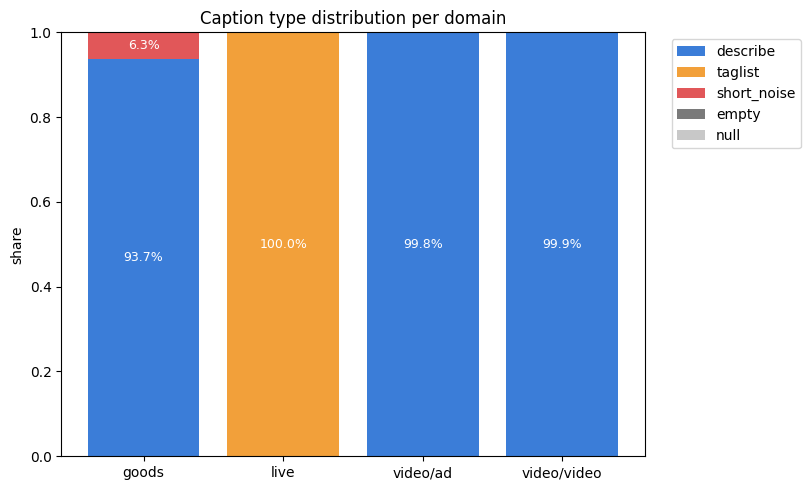

In [8]:
# 各 domain 下 caption 类型占比堆叠柱状图
types_order = ['describe', 'taglist', 'short_noise', 'empty', 'null']
domains_c = sorted(cap_stats.keys())
mat = np.zeros((len(types_order), len(domains_c)), dtype=float)
for j, d in enumerate(domains_c):
    total = sum(cap_stats[d].values())
    for i, t in enumerate(types_order):
        mat[i, j] = cap_stats[d].get(t, 0) / max(1, total)

fig, ax = plt.subplots(figsize=(1.6 * max(3, len(domains_c)) + 2, 5))
bottom = np.zeros(len(domains_c))
colors = ['#3b7dd8', '#f2a03a', '#e15759', '#7a7a7a', '#c8c8c8']
for i, t in enumerate(types_order):
    ax.bar(domains_c, mat[i], bottom=bottom, label=t, color=colors[i])
    for j, d in enumerate(domains_c):
        v = mat[i, j]
        if v > 0.03:
            ax.text(j, bottom[j] + v / 2, f'{v*100:.1f}%', ha='center', va='center', fontsize=9, color='white')
    bottom += mat[i]
ax.set_ylim(0, 1); ax.set_ylabel('share'); ax.set_title('Caption type distribution per domain')
ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.0))
plt.tight_layout()
plt.savefig(OUT_DIR / 'caption_type_stack.png', dpi=110)
plt.show()

## 结论 & 对 SFT 的直接指导

1. **懂物料任务的可用样本池** = `has_sid ∩ has_caption(type=describe)`。**不要**用 `type=taglist` 或 `short_noise` 的 caption 直接做描述↔SID 训练（否则模型会学到把 tag list 当描述输出）。
   - `taglist` 类型可以单独作为一种「关键词 → SID」任务的训练样本，等价于给模型一个更简短的 prompt。
2. **有 caption 无 SID 的 pid（异常）**：如果 `caption_no_sid` 数量非零，需要检查是否是数据错位；这些 pid 无法参与生成任务。
3. **无 tag 但有 SID 的 pid**：仍可用于纯 SID 生成任务（懂推荐），只是不能参与「主题匹配」（懂用户/兴趣演化任务）。
4. **caption 长度 P90/P99**（`caption_length_stats.csv`）：直接决定物料任务的 `max_source_length`。
5. **`goods` 域没有 tag**：兴趣演化任务里如果目标是「从内容到商品」，主题匹配只能靠 `caption` 里的关键词做召回。

### 产出物清单（`analysis/outputs/join/`）
- `coverage_matrix.csv`, `venn_regions.csv`, `venn_all_domains.png`
- `caption_type_stats.csv`, `caption_length_stats.csv`, `caption_type_stack.png`
- `orphan_sid_no_caption_{domain}.parquet` × 4
- `orphan_caption_no_sid_{domain}.parquet` × 4
- `orphan_sid_no_tag_{domain}.parquet` × 4
- `_pid_sets_cache.pkl`（每 domain 的 pid 集合，供后续 notebook 复用）
- `_caption_type_cache.pkl`

### 与后续 notebook 的衔接
- `_pid_sets_cache.pkl` 会被 §2.3 (caption 文本细粒度分析)、§2.4 (tag 分布) 复用，避免重复扫描。
- SFT 样本构造脚本可以直接用 `orphan_*.parquet` 作为 filter 白名单/黑名单。